# Model 5 -- Z' simplified dark matter: an exclusion study

ATLAS/CMS Dark Matter Forum, arXiv:1507.00966.


Simplified $Z'$-mediator models couple a new massive vector boson to quarks, leptons, and a dark-matter fermion with universal couplings $g_q,g_\ell,g_\chi$. They are the standard benchmark the LHC Dark Matter Forum uses for translating monojet, dijet, and dilepton searches into $(M_{Z'},m_\chi)$ exclusion limits, and are deliberately built so there is nothing to *fit* -- only a region to map.

**What this notebook does.** BSMScanner separates *what a model is* (a declarative YAML specification: parameters, priors, derived quantities, observables, validity conditions, likelihoods) from *how it is scanned* (one of several interchangeable search engines). This notebook loads the model below, runs a small, fast scan live so you can see the mechanics end to end, and then loads the matched-budget, fixed-seed comparison across all four engines from the companion paper's benchmark study, together with its best-fit / allowed-region result and figure. The live demo uses a short budget and an illustrative seed — it is not the published comparison, and is not expected to reproduce it exactly.


## 1. Load the framework and the model

In [1]:
import sys, pathlib
REPO_ROOT = pathlib.Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT / "python"))

import pandas as pd
from bsm_scanner import load_model, compile_model, run_scan
import bsm_scanner

print("bsm_scanner", bsm_scanner.__version__)
print("repo root  :", REPO_ROOT)

bsm_scanner 0.1.2
repo root  : /sessions/rcw-012reqeed7ksc6e9zagwhruw/mnt/BSMScanner


## 2. The model specification

Every scanned parameter, its prior, and its range come straight out of the model's YAML file (`../models/zprime_simplified/model.yaml`); nothing here is hand-written Python.

In [2]:
model = load_model("../models/zprime_simplified/model.yaml")
print("model    :", model.metadata.name)
print("params   :", len(model.parameters), "scanned")
print("theory checks:", len(model.theory_checks))
print("likelihood terms:", len(model.likelihoods))

pd.DataFrame(
    [{"name": p.name, "prior": p.prior.value, "lower": p.lower, "upper": p.upper, "default": p.default}
     for p in model.parameters]
)

model    : zprime_simplified_dm
params   : 5 scanned
theory checks: 2
likelihood terms: 3


,name,prior,lower,upper,default
0,MZp,log,100.000,10000.0,3000.00
1,mchi,log,1.000,5000.0,500.00
2,gq,log,0.001,2.0,0.25
3,gl,flat,0.000,1.0,0.00
4,gchi,log,0.001,2.0,1.00


Likelihood terms declared on the model:

In [3]:
pd.DataFrame(
    [{"name": t.name, "kind": t.kind.value, "observable": t.observable} for t in model.likelihoods]
)

,name,kind,observable
0,narrow_width,hard_cut,WidthFractionProxy
1,monojet_proxy_limit,hard_cut,MonojetRateProxy
2,dilepton_proxy_limit,hard_cut,DileptonRateProxy


For reference, here is the parameter block exactly as written in the YAML (this is the entire declarative input the physics below is built from):

In [4]:
print(pathlib.Path("../models/zprime_simplified/model.yaml").read_text())

metadata:
  name: zprime_simplified_dm
  version: 0.1.0
  description: Vector-mediator Zprime simplified dark-matter benchmark with quark, lepton, and Dirac-DM couplings plus width, resonance, and collider-proxy observables.
  tags: [zprime, simplified_model, dark_matter, vector_mediator]
parameters:
- {name: MZp, value_type: real, scan: true, lower: 100.0, upper: 10000.0, default: 3000.0, prior: log}
- {name: mchi, value_type: real, scan: true, lower: 1.0, upper: 5000.0, default: 500.0, prior: log}
- {name: gq, value_type: real, scan: true, lower: 0.001, upper: 2.0, default: 0.25, prior: log}
- {name: gl, value_type: real, scan: true, lower: 0.0, upper: 1.0, default: 0.0, prior: flat}
- {name: gchi, value_type: real, scan: true, lower: 0.001, upper: 2.0, default: 1.0, prior: log}
constants:
- {name: pi_ref, value: 3.141592653589793}
derived_scalars:
- {name: beta_chi, value_type: real, expression: "sqrt(max(1.0 - 4.0*mchi**2/MZp**2, 0.0))"}
- {name: width_quarks_proxy, value_type: rea

## 3. A quick, live scan

This runs `serial_random` for `3000` evaluations at a throwaway seed, right here, so you can see the mechanics end to end in a few seconds. It is deliberately small and is **not** the matched-budget comparison used in the study below.

In [5]:
# A small, fast, live demo -- NOT the matched-budget study below.
model.scan.engine = "serial_random"
model.scan.seed = 1
model.scan.settings["max_evaluations"] = 3000

compiled = compile_model(model)
demo = run_scan(model, compiled, run_directory="runs/zprime_simplified_demo")

n_eval = demo.summary["evaluations"]
n_valid = demo.summary["valid_points"]
print("evaluations  :", n_eval)
print("valid points :", n_valid, "(%.1f%% of this quick run)" % (100.0 * n_valid / n_eval))
print("best nLL in this quick run:", demo.summary["best_metric_value"])

points = pd.read_csv(demo.points_path)
points.head()

evaluations  : 3000
valid points : 1976 (65.9% of this quick run)
best nLL in this quick run: 0.0


,evaluation,status,valid,failure_reason,scanner_target,metric_value,total_nll,param::MZp,param::mchi,param::gq,...,param::gchi,output::MediatorMass,output::DarkMatterMass,output::WidthFractionProxy,output::MonojetRateProxy,output::DileptonRateProxy,output::ResonantDMOpen,likelihood::dilepton_proxy_limit,likelihood::monojet_proxy_limit,likelihood::narrow_width
0,1,ok,True,NaN,0.000000e+00,0.000000e+00,0,185.248,3.1957,0.030866,...,0.014399,185.247898,3.195697,0.000531,0.000168,0.000358,1.0,0.0,0.0,0.0
1,2,ok,True,NaN,0.000000e+00,0.000000e+00,0,6648.380,55.1186,0.001761,...,0.125002,6648.384003,55.118580,0.052098,0.000000,0.000000,1.0,0.0,0.0,0.0
2,3,ok,False,likelihood_input_invalid: dilepton_proxy_limit,1.000000e+12,1.000000e+12,0,150.975,114.1010,0.404264,...,0.024101,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,ok,False,likelihood_input_invalid: dilepton_proxy_limit,1.000000e+12,1.000000e+12,0,315.905,12.0115,0.448236,...,0.007782,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,ok,True,NaN,0.000000e+00,0.000000e+00,0,373.322,589.5140,0.032530,...,0.011538,373.322040,589.514422,0.015426,0.000007,0.005107,0.0,0.0,0.0,0.0


## 4. The published engine comparison

All three likelihood terms are hard cuts -- there is not one continuous term. Every valid point has $n$LL$=0$ exactly, verified over a 60-point grid spanning the full prior box. This is a pure exclusion-region problem: coverage is the only meaningful metric. Coverage counts occupied cells on a 30x30 grid over $(\log M_{Z'},\log m_\chi)$.

In [6]:
pd.DataFrame([{'engine': 'serial_random', 'evaluations': 30000, 'valid': 19654, 'valid_pct': '65.5%', 'best_nLL': 0.0, 'coverage': '900/900'}, {'engine': 'basin_scan', 'evaluations': 29644, 'valid': 24084, 'valid_pct': '81.2%', 'best_nLL': 0.0, 'coverage': '898/900'}, {'engine': 'adaptive_diver', 'evaluations': 20100, 'valid': 18677, 'valid_pct': '92.9%', 'best_nLL': 0.0, 'coverage': '439/900'}, {'engine': 'de_scipy', 'evaluations': 4358, 'valid': 2497, 'valid_pct': '57.3%', 'best_nLL': 0.0, 'coverage': '215/900'}])[['engine', 'evaluations', 'valid', 'valid_pct', 'best_nLL', 'coverage']]

,engine,evaluations,valid,valid_pct,best_nLL,coverage
0,serial_random,30000,19654,65.5%,0.0,900/900
1,basin_scan,29644,24084,81.2%,0.0,898/900
2,adaptive_diver,20100,18677,92.9%,0.0,439/900
3,de_scipy,4358,2497,57.3%,0.0,215/900


`serial_random` wins outright with perfect 900/900 coverage -- the only model in the study where it is the best choice: with no objective, there is nothing for an optimiser to exploit, and uniform sampling is exactly the right algorithm. `adaptive_diver` has the *highest* valid fraction (92.9%) but covers less than half the plane -- its difference-vector updates still contract the population even on a flat objective. High efficiency at finding valid points is not the same as mapping them.

## 5. Allowed region (pooling all engines, 50,643 allowed points)

In [7]:
pd.DataFrame([{'quantity': 'M_Zprime', 'result': '100.1 -- 9,999.9 GeV (full prior range)'}, {'quantity': 'm_chi', 'result': '1.00 -- 4,999.6 GeV (full prior range)'}, {'quantity': 'points with M_Zprime > 2 m_chi (DM channel open)', 'result': '69.2%'}, {'quantity': 'max width fraction', 'result': '0.2999 (cut 0.30)'}, {'quantity': 'max monojet proxy', 'result': '0.1987 (cut 0.20)'}])[['quantity', 'result']]

,quantity,result
0,M_Zprime,"100.1 -- 9,999.9 GeV (full prior range)"
1,m_chi,"1.00 -- 4,999.6 GeV (full prior range)"
2,points with M_Zprime > 2 m_chi (DM channel open),69.2%
3,max width fraction,0.2999 (cut 0.30)
4,max monojet proxy,0.1987 (cut 0.20)


The cuts constrain *couplings at fixed mass* rather than the masses themselves, so the full $(M_{Z'},m_\chi)$ prior range survives -- every mass point is allowed for some choice of couplings. At the DM Forum benchmark couplings ($g_q=0.25,g_\chi=1,g_\ell=0$) the monojet cut alone requires $M_{Z'}\ge747$ GeV.

### Figure

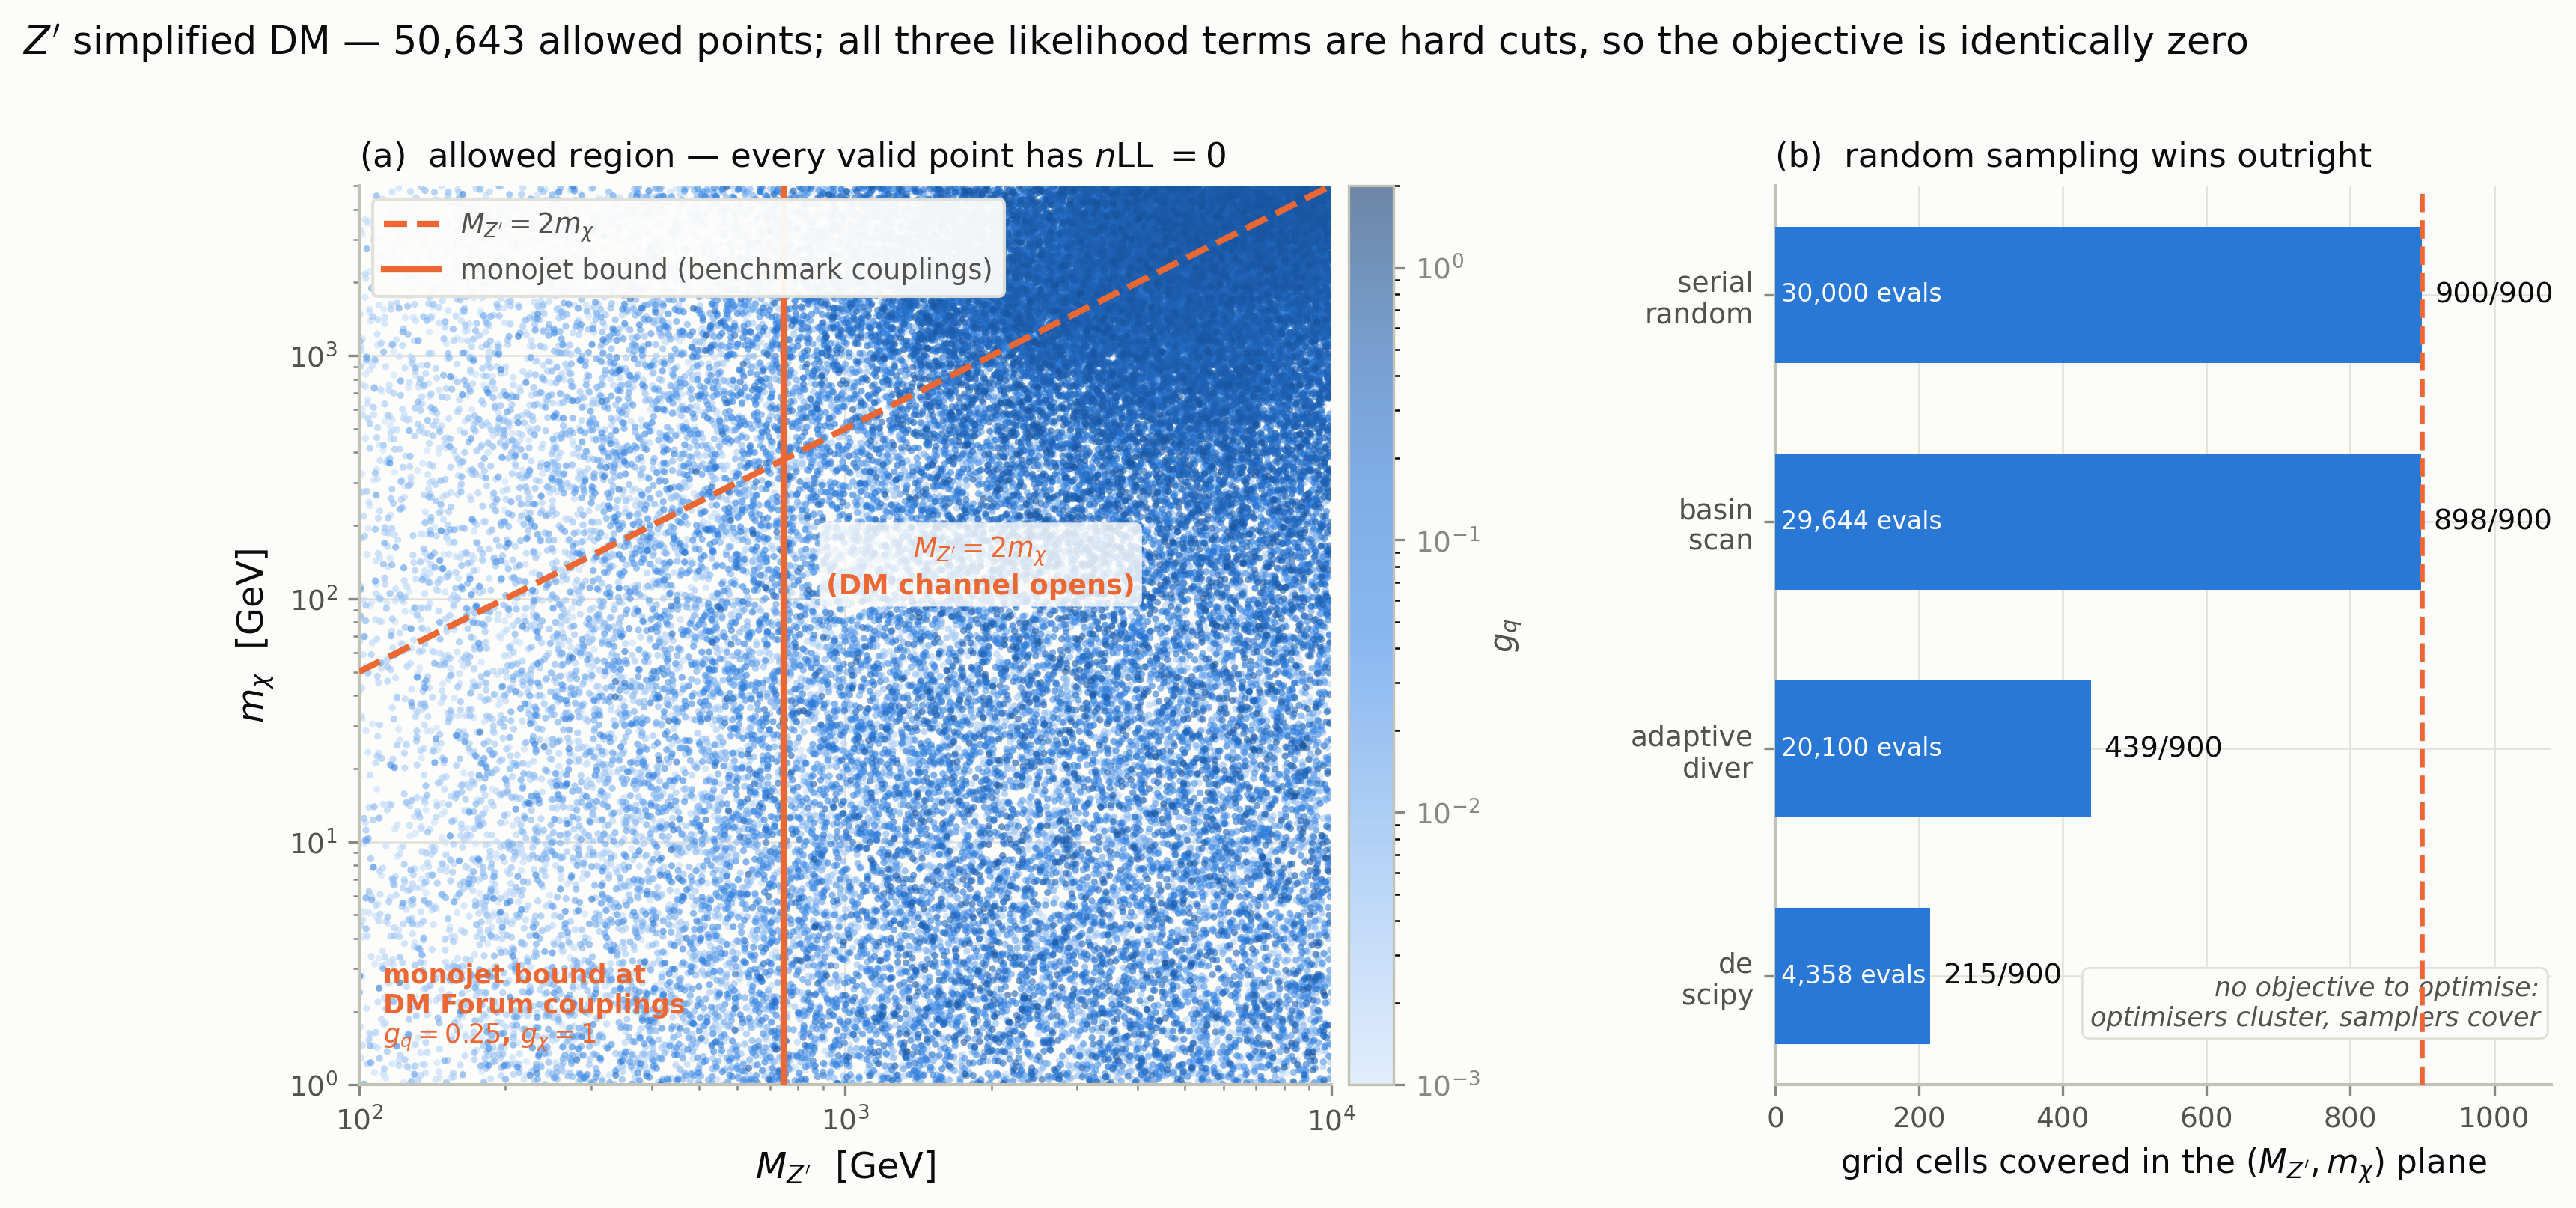

In [8]:
from IPython.display import Image, display
display(Image(filename="figures/zprime_simplified.png"))

Coverage of the (M_Z', m_chi) plane achieved by each engine, and the monojet-limited benchmark line.

## 6. Caveats

These are deliberately crude proxies: the monojet and dilepton rates are $g^2g^2/M^4$ scalings with no acceptance, luminosity, or shape information, and the width is a tree-level partial-width sum. Real ATLAS/CMS limits, and the relic-density constraint (absent entirely here), would carve a much narrower region than what survives in this benchmark.

## 7. Reproducing the full study

The cell below is exactly the pattern used to produce the table in section 4 — shown, not executed, since a full matched-budget run can take a while.

In [ ]:
# NOT executed in this notebook (can take from seconds to several minutes per
# engine). Reproduces the matched-budget comparison from the study: seed
# 20260816, ~30k evaluations, one row per engine.
rows = []
for engine in ["serial_random", "de_scipy", "adaptive_diver", "basin_scan"]:
    m = load_model("../models/zprime_simplified/model.yaml")
    m.scan.engine = engine
    m.scan.seed = 20260816
    m.scan.settings["max_evaluations"] = 30000
    c = compile_model(m)
    r = run_scan(m, c, run_directory=f"runs/{engine}_matched")
    rows.append({"engine": engine, **r.summary})
pd.DataFrame(rows)

---
BSMScanner: a declarative parameter-scanning framework for BSM physics. See the companion paper for the full seven-benchmark methodology study, and `notebooks/t43i_b1.ipynb` for a worked physics application built on top of it.